In [3]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift
from utility.my_colors import palette_light

from sparcl.client import SparclClient
from scipy.interpolate import interp1d
from lmfit import Model
from astropy.table import Table

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings


hamann_fits_path = "data/local/ERQs_core_all_MNRAS.fits"
search_log_path = "data/local/hamann-objects-desi-search-log.json"

In [4]:
hamann_data = Table.read("data/local/ERQs_core_all_MNRAS.fits").to_pandas() #pd.read_csv(hamann_erq_path,index_col=0)

hamann_data["sdss_name"] = hamann_data["sdss_name"].astype("string")

match_df = pd.read_json(search_log_path)
match_df = match_df[["SDSS_id","best_match_id"]].copy()
match_df["SDSS_id"] = match_df["SDSS_id"].str[1:]

match_df = match_df.rename(columns={"best_match_id":"DESI_targetid", "SDSS_id":"sdss_name"})

hamann_erq = hamann_data.merge(match_df,on="sdss_name",how="left")

hamann_erq

,sdss_name,Plate,MJD,FiberID,ThingID,z_dr12,i,i_err,W3,W3_snr,...,kt75,kt80,rew_di,rewe_di,fwhm_di,qflag,rew_nv,frat_nv_civ,nvflag,DESI_targetid
0,000610.67+121501.2,5649,55912,288,220079389,2.309943,22.101451,0.160805,14.087,35.1,...,0.455485,0.372288,102.007661,6.075000,4508.508813,0,192.343862,1.880187,0,39628078766358575
1,000746.19+122223.9,6176,56264,194,221814072,2.429000,21.314343,0.079014,16.369,7.0,...,0.383122,0.284162,213.628344,4.754235,2550.825969,0,64.601598,0.388502,0,39628078770555722
2,002400.25+245031.9,6279,56243,28,328146826,2.809255,21.556824,0.090767,15.522,14.6,...,0.455389,0.372201,134.821509,10.120908,3694.810492,0,205.776721,2.455813,0,39628365275075274
3,004713.21+264024.7,6286,56301,800,342571394,2.563943,20.435463,0.038392,15.714,13.2,...,0.413071,0.325082,100.642397,5.476974,3662.920844,0,141.614347,1.923201,0,Not found
4,005044.95-021217.6,4370,55534,980,60738765,2.254000,21.473060,0.078552,16.760,4.6,...,0.262998,0.193256,148.782256,6.993491,5445.426756,0,46.553849,0.609687,0,39627730584601174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,223754.52+065026.6,5058,56208,124,172688138,2.608809,21.960453,0.106963,16.169,3.9,...,0.440905,0.356129,136.337135,3.430820,1318.560329,0,109.072962,1.034336,0,39627953214063409
93,225438.30+232714.5,6588,56536,390,315135318,3.087494,22.010175,0.120658,16.552,5.3,...,0.442837,0.358143,354.839828,22.560964,4906.586551,0,211.097222,0.660819,0,Not found
94,232326.17-010033.1,4210,55444,93,75229201,2.356070,22.410147,0.200206,15.218,19.1,...,0.454002,0.370693,260.264938,4.465699,4186.298391,0,565.970265,2.160131,0,39627766454292268
95,232828.47+044346.8,4283,55864,592,153323514,2.563872,21.532625,0.144071,16.066,9.3,...,0.437510,0.352179,356.552346,4.328203,1575.355245,0,122.280344,0.373535,0,39627905315113841


In [6]:
client = SparclClient()

idxs = [int(x) for x in hamann_erq["DESI_targetid"].head(10) if x != "Not found"]

output_fields = ['specid', 'redshift', 'wavelength', 'flux', 'ivar', 'spectype', 'targetid', 'redshift_warning']

spectra = client.retrieve_by_specid(idxs, dataset_list=["DESI-DR1"], include=output_fields)

spectra_df = pd.DataFrame(spectra.data[1:])
spectra_df

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


,targetid,redshift,spectype,redshift_warning,specid,flux,ivar,wavelength,_dr
0,39628078766358575,2.199301,QSO,0,39628078766358575,"[6.083261489868164, 7.300170421600342, 5.58030...","[0.09443012624979019, 0.11103168874979019, 0.1...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
1,39627730584601174,1.782655,QSO,0,39627730584601174,"[0.4372713565826416, 2.111987352371216, -4.080...","[0.07881371676921844, 0.0627162829041481, 0.06...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
2,39628365275075274,2.837482,QSO,0,39628365275075274,"[0.7628244161605835, -1.0635453462600708, 0.83...","[0.33674854040145874, 0.3539333641529083, 0.37...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
3,39628504643403849,2.360326,QSO,0,39628504643403849,"[0.29033735394477844, 3.1691737174987793, -2.4...","[0.05054178088903427, 0.09497752040624619, 0.0...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
4,39627706643513715,2.536830,QSO,0,39627706643513715,"[3.230962038040161, -2.0705037117004395, 2.608...","[0.17553436756134033, 0.1668706238269806, 0.18...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
5,39628078770555722,2.430429,QSO,0,39628078770555722,"[1.2459850311279297, -3.726759195327759, -1.50...","[0.0447843037545681, 0.056199029088020325, 0.0...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
6,39627640176382892,2.452858,QSO,0,39627640176382892,"[2.040266513824463, 2.7940256595611572, -1.077...","[0.13237154483795166, 0.1565820425748825, 0.15...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1


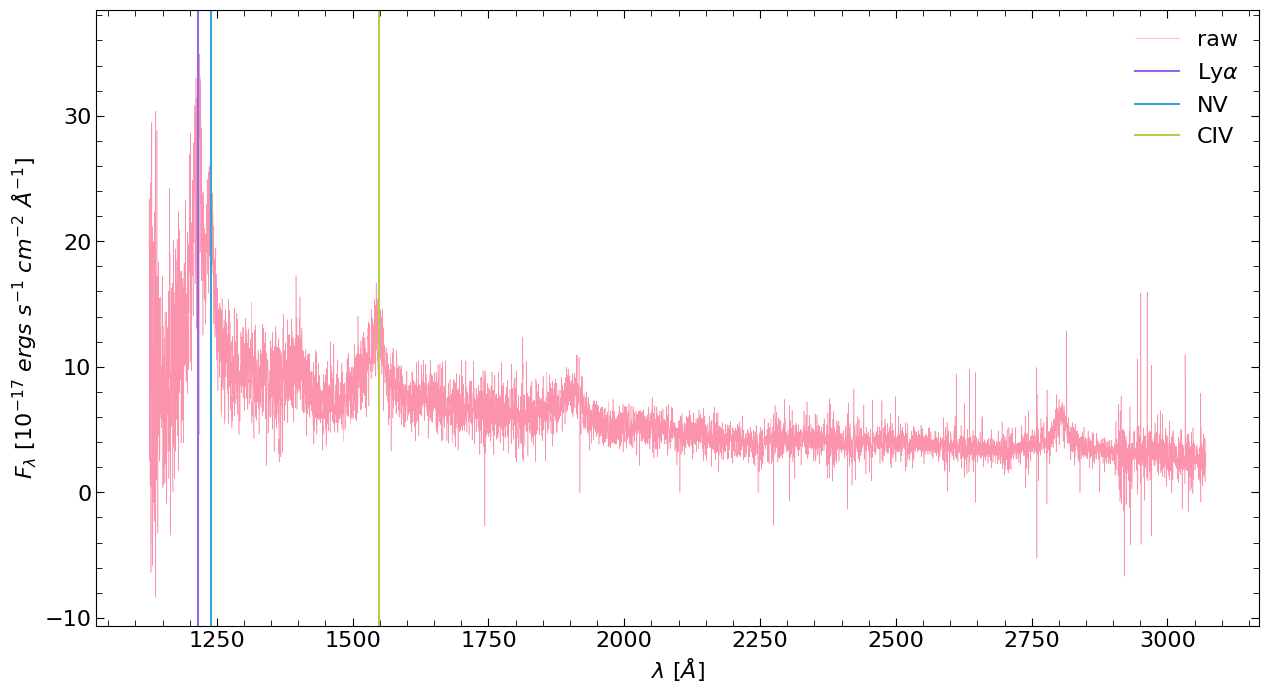

In [30]:
idx = 0

lam = np.array(spectra_df["wavelength"][idx])
flux = np.array(spectra_df["flux"][idx])
ivar = np.array(spectra_df["ivar"][idx])
z = spectra_df["redshift"][idx]

lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)

plot_spectrum(lam, flux, line_lambda=[1215,1240,1549], line_label=[r"Ly$\alpha$","NV","CIV"], add_smoothed=False)

In [39]:
continuum_windows = [
    (1425, 1470),   # blue side of CIV, relatively clean
    (1680, 1710),   # red side of CIV, between HeII and CIII]
    (1760, 1810),   # far red continuum anchor
]
 
# CIV emission line region (used for significance check and BAL detection)
civ_region = (1500, 1600)   # Å, rest-frame
 
# Quality cut thresholds
max_powerlaw_slope = 3.0    # reject if |alpha| > this (unrealistically steep)
bal_sigma_threshold = -2.0  # reject if median flux in CIV window is this many sigma BELOW the continuum (broad absorption)
min_emission_sigma = 2.0    # reject if peak emission above continuum is less than this many sigma (no significant emission)

#### spike removal

In [19]:
def remove_spikes(wave, flux, ivar=None, sigma_thresh=5.0, window=11):
    """
    Detect and remove narrow spikes (cosmic rays / noise anomalies).
 
    A pixel is flagged as a spike if its flux deviates from the local median
    by more than `sigma_thresh` * local MAD. Flagged pixels are replaced by
    linear interpolation from their neighbours.
 
    Parameters
    ----------
    wave : array_like
        Wavelength array (Å).
    flux : array_like
        Flux array (arbitrary units).
    ivar : array_like or None
        Inverse variance array. If provided, zero-ivar pixels are also masked.
    sigma_thresh : float
        Number of sigma above/below the local median to flag a spike.
    window : int
        Half-width (in pixels) of the local median filter window.
 
    Returns
    -------
    flux_clean : ndarray
        Flux array with spikes replaced by interpolated values.
    spike_mask : ndarray of bool
        True where a spike was detected and replaced.
    """
    flux = np.array(flux, dtype=float)
    wave = np.array(wave, dtype=float)
    n = len(flux)
    spike_mask = np.zeros(n, dtype=bool)
 
    # Flag zero/negative ivar pixels
    if ivar is not None:
        spike_mask |= (np.array(ivar) <= 0)
 
    # Rolling median and MAD-based sigma clipping
    for i in range(n):
        lo = max(0, i - window)
        hi = min(n, i + window + 1)
        neighbours = np.concatenate([flux[lo:i], flux[i+1:hi]])
        if len(neighbours) < 3:
            continue
        med = np.median(neighbours)
        mad = np.median(np.abs(neighbours - med))
        sigma = 1.4826 * mad  # MAD -> Gaussian sigma equivalent
        if sigma > 0 and np.abs(flux[i] - med) > sigma_thresh * sigma:
            spike_mask[i] = True
 
    # Interpolate over flagged pixels using clean neighbours
    flux_clean = flux.copy()
    if spike_mask.any():
        good = ~spike_mask
        if good.sum() < 2:
            warnings.warn("Too many spikes — cannot interpolate reliably.")
            return flux_clean, spike_mask
        interp_fn = interp1d(wave[good], flux[good],
                             kind='linear', bounds_error=False,
                             fill_value='extrapolate')
        flux_clean[spike_mask] = interp_fn(wave[spike_mask])
 
    return flux_clean, spike_mask


flux_clean, spike_mask = remove_spikes(lam,flux,ivar=ivar)

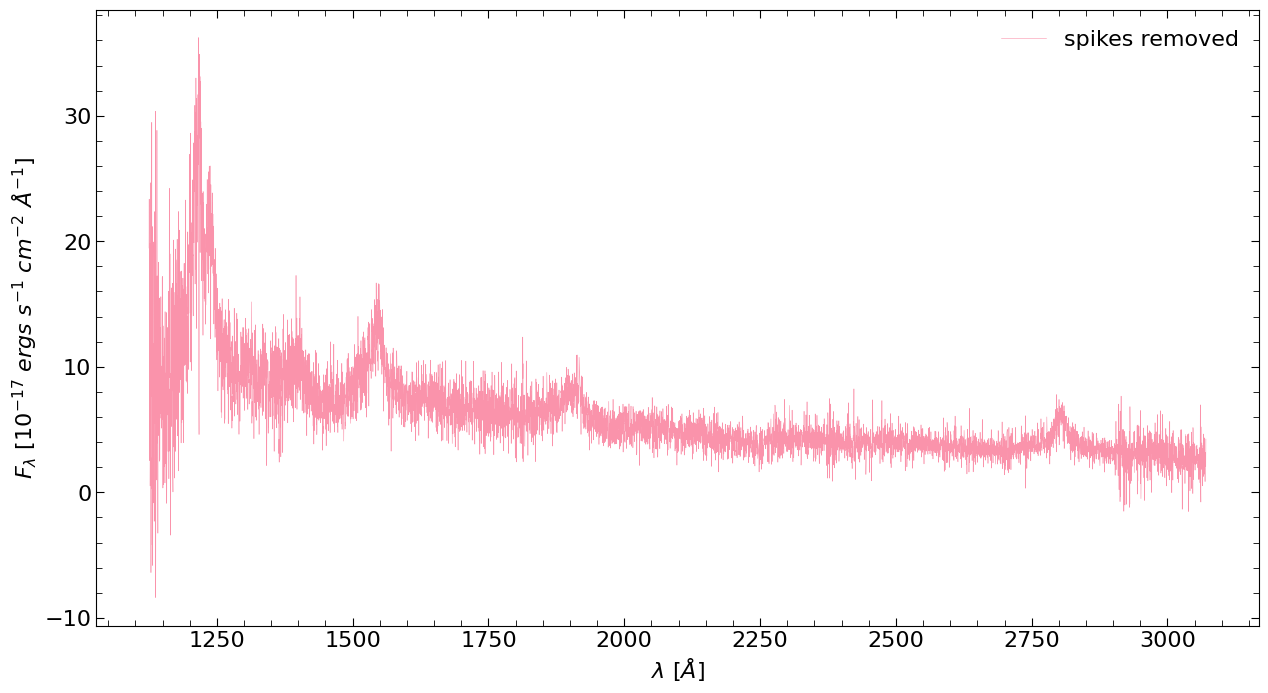

In [29]:
plot_spectrum(lam, flux_clean, flux_label="spikes removed", add_smoothed=False)

#### continuum fit

In [40]:
def _powerlaw(x, amplitude, alpha):
    """F(λ) = amplitude * (λ / λ_ref) ^ alpha"""
    return amplitude * (x ** alpha)
 
 
def fit_continuum(wave, flux, ivar=None,
                  windows=continuum_windows,
                  lambda_ref=1700.0):
    """
    Fit a power-law continuum using median fluxes in emission-free windows.
 
    Parameters
    ----------
    wave : array_like
        Rest-frame wavelength array (Å).
    flux : array_like
        Flux array (spike-cleaned).
    ivar : array_like or None
        Inverse variance. Used to weight the window medians if provided.
    windows : list of (float, float)
        Rest-frame wavelength windows free of emission lines.
    lambda_ref : float
        Reference wavelength for the power law (normalisation pivot).
 
    Returns
    -------
    result : lmfit ModelResult
        Full lmfit fit result (contains best-fit params, uncertainties, etc.)
    continuum : ndarray
        Best-fit continuum evaluated at every wavelength in `wave`.
    window_mask : ndarray of bool
        True for pixels used in the fit.
    """
    wave = np.array(wave, dtype=float)
    flux = np.array(flux, dtype=float)
 
    # Build window mask and compute per-window median flux
    window_waves = []
    window_fluxes = []
    window_weights = []
 
    for w0, w1 in windows:
        mask = (wave >= w0) & (wave <= w1) & np.isfinite(flux)
        if mask.sum() < 3:
            continue
        wc = 0.5 * (w0 + w1)          # window centre wavelength
        med_flux = np.median(flux[mask])
        if ivar is not None:
            med_ivar = np.median(ivar[mask])
            weight = np.sqrt(max(med_ivar, 0))
        else:
            weight = 1.0
        window_waves.append(wc)
        window_fluxes.append(med_flux)
        window_weights.append(weight)
 
    if len(window_waves) < 2:
        raise ValueError("Fewer than 2 continuum windows have data — "
                         "cannot fit continuum.")
 
    xdata = np.array(window_waves) / lambda_ref
    ydata = np.array(window_fluxes)
    weights = np.array(window_weights)
    if weights.sum() == 0:
        weights = np.ones_like(weights)
 
    # lmfit power-law model
    plaw_model = Model(_powerlaw)
    params = plaw_model.make_params(
        amplitude=dict(value=np.median(ydata), min=0),
        alpha=dict(value=-1.5, min=-10, max=10),
    )
 
    result = plaw_model.fit(ydata, params, x=xdata, weights=weights)
 
    # Evaluate continuum across the full spectrum
    continuum = result.best_values['amplitude'] * \
                ((wave / lambda_ref) ** result.best_values['alpha'])
 
    # Full-spectrum window mask (for plotting)
    window_mask = np.zeros(len(wave), dtype=bool)
    for w0, w1 in windows:
        window_mask |= (wave >= w0) & (wave <= w1)
 
    return result, continuum, window_mask


result, continuum, window_mask = fit_continuum(lam, flux_clean, ivar=ivar)

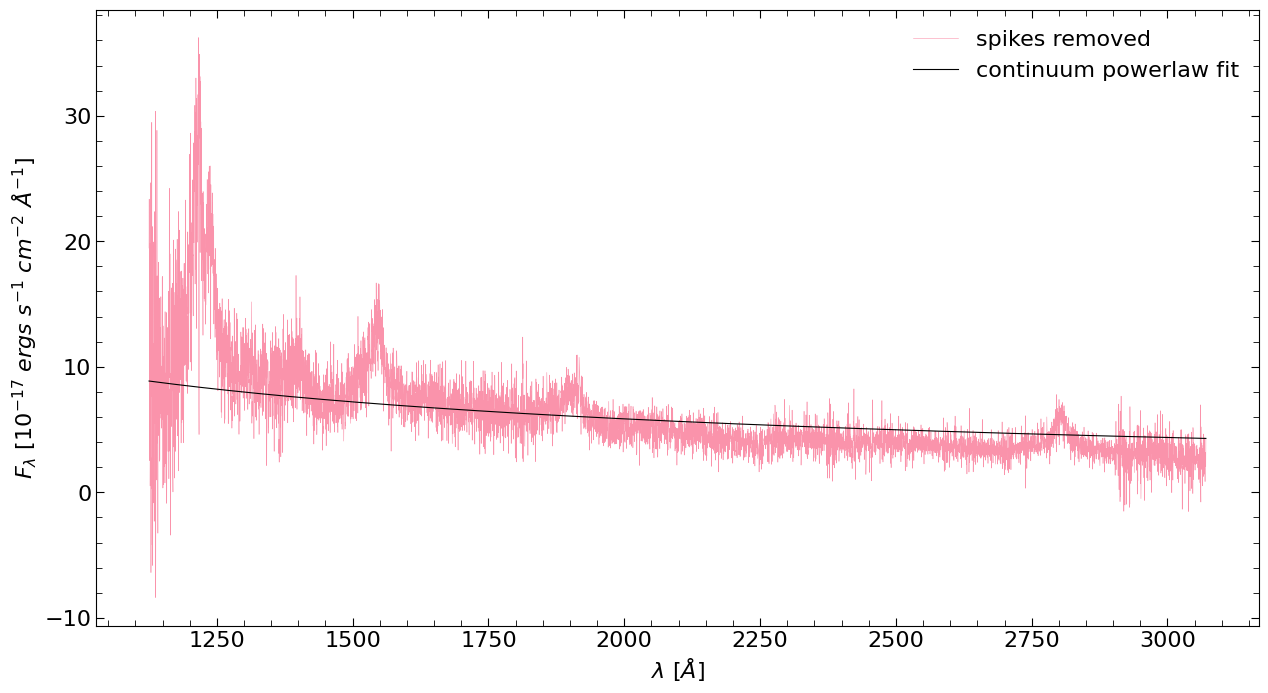

In [38]:
plot_spectrum(lam, flux_clean, flux_label="spikes removed", add_smoothed=False, additional_flux=continuum, additional_flux_label="continuum powerlaw fit")

#### hamann quality cuts

In [ ]:
def quality_cuts(wave, flux, continuum, fit_result,
                 civ_region=CIV_REGION,
                 max_slope=MAX_POWERLAW_SLOPE,
                 bal_sigma=BAL_SIGMA_THRESHOLD,
                 min_emission_sigma=MIN_EMISSION_SIGMA):
    """
    Apply the three quality cuts from the paper.
 
    Parameters
    ----------
    wave : array_like
        Rest-frame wavelength array.
    flux : array_like
        Spike-cleaned flux.
    continuum : array_like
        Best-fit continuum flux.
    fit_result : lmfit ModelResult
        Result from fit_continuum.
    civ_region : (float, float)
        Wavelength range of the CIV emission line.
    max_slope : float
        Maximum allowed |alpha| before the fit is considered unrealistic.
    bal_sigma : float
        Sigma threshold for broad absorption detection (negative value).
    min_emission_sigma : float
        Minimum sigma for a significant emission detection.
 
    Returns
    -------
    rejected : bool
        True if the spectrum fails any quality cut.
    reason : str or None
        Human-readable reason for rejection, or None if accepted.
    flags : dict
        Dict of individual flag values for inspection.
    """
    alpha = fit_result.best_values['alpha']
    residual = np.array(flux) - np.array(continuum)
    noise = _estimate_noise(residual, wave)
 
    civ_mask = (np.array(wave) >= civ_region[0]) & \
               (np.array(wave) <= civ_region[1])
 
    flags = {}
 
    # Cut 1: Unrealistically steep continuum
    flags['steep_continuum'] = abs(alpha) > max_slope
    if flags['steep_continuum']:
        return True, f"Continuum too steep (alpha={alpha:.2f})", flags
 
    # Cut 2: Broad absorption at CIV wavelengths
    if civ_mask.sum() > 0 and noise > 0:
        med_residual_civ = np.median(residual[civ_mask])
        bal_detection = med_residual_civ / noise
        flags['bal_detected'] = bal_detection < bal_sigma
        if flags['bal_detected']:
            return True, \
                f"Broad absorption detected at CIV (residual S/N={bal_detection:.1f})", \
                flags
    else:
        flags['bal_detected'] = False
 
    # Cut 3: No significant emission above continuum
    if civ_mask.sum() > 0 and noise > 0:
        peak_emission = np.max(residual[civ_mask]) / noise
        flags['no_emission'] = peak_emission < min_emission_sigma
        if flags['no_emission']:
            return True, \
                f"No significant CIV emission (peak S/N={peak_emission:.1f})", \
                flags
    else:
        flags['no_emission'] = True
        return True, "CIV region not covered by spectrum", flags
 
    return False, None, flags
 
 
def _estimate_noise(residual, wave, window=continuum_window):
    """Estimate noise from the scatter in continuum window residuals."""
    mask = np.zeros(len(wave), dtype=bool)
    for w0, w1 in window:
        mask |= (np.array(wave) >= w0) & (np.array(wave) <= w1)
    if mask.sum() < 5:
        return np.std(residual)
    return 1.4826 * np.median(np.abs(residual[mask] -
                                     np.median(residual[mask])))